# Nomor 2a
Lakukan Exploratory Data Analysis
untuk memeriksa kondisi data yang anda miliki, seperti
aspect ratio & resolution. Lalu pisahkan data anda menjadi
train, validation, dan test dengan proporsi 70:15:15!
Lakukan pre-processing pada data anda.

## Load Dataset

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## EDA

### Check Total & Distribution

In [16]:
base_path = "/content/drive/MyDrive/2B/2C/Cherry/data"

In [17]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

class_counts = {}
image_sizes = []
aspect_ratios = []

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)

    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        class_counts[class_name] = len(files)

        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                img_path = os.path.join(class_path, file)

                try:
                    img = Image.open(img_path)
                    w, h = img.size

                    image_sizes.append((w, h))
                    aspect_ratios.append(w / h)
                except:
                    continue

print("Total images:", len(image_sizes))

print("\nTotal per class:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

Total images: 3642

Total per class:
Cherry Normal leaf: 500
Cherry Leaf Scorch: 1101
Cherry brown_spot: 614
Cherry_shot hole disease: 440
Cherry purple leaf spot: 987


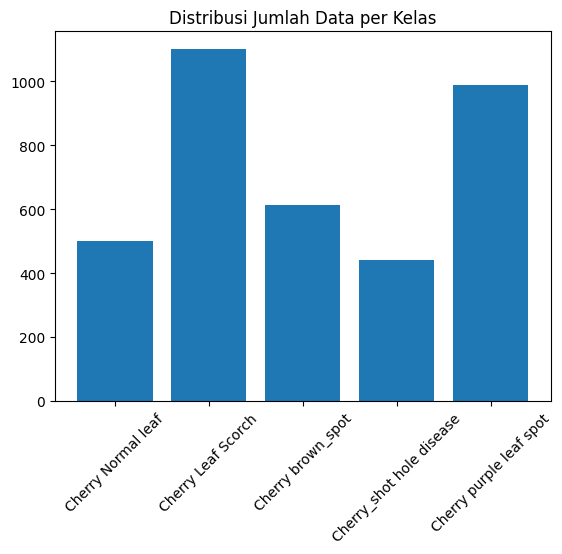

In [18]:
plt.figure()
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Distribusi Jumlah Data per Kelas")
plt.show()

Dataset tidak seimbang (imbalanced)
   
Kelas dengan jumlah terbesar:
Cherry Leaf Scorch (1101 gambar)  
Kelas dengan jumlah terkecil:
Cherry Shot Hole Disease (440 gambar)

Selisih antara kelas terbesar dan terkecil cukup signifikan (661 gambar), sehingga berpotensi menyebabkan:
- Model lebih cenderung memprediksi kelas dengan data lebih banyak
- Performa pada kelas minoritas bisa lebih rendah.

### Check Resolution & Aspect Ratio

In [19]:
sizes = []
ratios = []

for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            width, height = img.size

            sizes.append((width, height))
            ratios.append(width / height)
        except:
            continue

print("Sample size:", sizes[:10])
print("Sample aspect ratio:", ratios[:10])

print("Total unique size:", len(set(sizes)))

Sample size: [(800, 1000), (800, 1000), (800, 1000), (800, 1000), (800, 1000), (800, 1000), (800, 1000), (800, 1000), (800, 1000), (800, 1000)]
Sample aspect ratio: [0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8, 0.8]
Total unique size: 1


Seluruh gambar dalam dataset memiliki:
- Resolution yang seragam, yaitu 800 × 1000 pixel
- Aspect ratio yang konsisten, yaitu:
800 / 1000 = 0.8

Hal ini menunjukkan bahwa:
- Tidak terdapat variasi ukuran gambar
- Tidak terdapat perbedaan proporsi (semua gambar memiliki bentuk yang sama, cenderung portrait)

**Implikasi terhadap Model**  
Karena ukuran dan aspect ratio sudah seragam:
- Model CNN dapat langsung memproses gambar tanpa perlu penyesuaian ukuran yang kompleks
- Tidak ada risiko distorsi akibat perbedaan aspect ratio

Preprocessing tetap diperlukan untuk menyesuaikan ukuran input model (misalnya menjadi 224 × 224) dan normalisasi nilai pixel

## Split Data

In [20]:
import random
import shutil

input_dir = base_path
output_dir = "dataset_split"

splits = ["train", "val", "test"]
ratio = [0.7, 0.15, 0.15]

# folder output
for split in splits:
    for class_name in os.listdir(input_dir):
        os.makedirs(os.path.join(output_dir, split, class_name), exist_ok=True)

# split data
for class_name in os.listdir(input_dir):
    class_path = os.path.join(input_dir, class_name)
    images = os.listdir(class_path)

    random.shuffle(images)

    total = len(images)
    train_end = int(0.7 * total)
    val_end = int(0.85 * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, "train", class_name, img))

    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, "val", class_name, img))

    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_dir, "test", class_name, img))

print("Done.")

Done.


## Preprocessing

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Train (Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation & Test (without augmentation)
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [22]:
train_generator = train_datagen.flow_from_directory(
    "dataset_split/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    "dataset_split/val",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    "dataset_split/test",
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3293 images belonging to 5 classes.
Found 997 images belonging to 5 classes.
Found 1006 images belonging to 5 classes.


Seluruh gambar di-resize menjadi ukuran 224x224 piksel agar memiliki dimensi yang seragam sesuai dengan input model. Selanjutnya, dilakukan normalisasi nilai pixel dari rentang 0-255 menjadi 0-1 dengan membagi setiap pixel dengan 255 untuk meningkatkan stabilitas dan mempercepat proses training. Pada data training, diterapkan data augmentation seperti rotasi, zoom, dan horizontal flipping untuk meningkatkan variasi data serta membantu mengatasi ketidakseimbangan kelas (imbalanced dataset). Sementara itu, data validation dan testing hanya dilakukan normalisasi tanpa augmentasi agar evaluasi model tetap objektif. Data kemudian dimuat menggunakan metode flow_from_directory yang membaca gambar berdasarkan struktur folder dan memprosesnya dalam bentuk batch untuk efisiensi memori, dengan label dikonversi ke bentuk kategorikal (one-hot encoding) karena merupakan permasalahan klasifikasi multi-kelas.

## Class Weight

In [23]:
from sklearn.utils.class_weight import compute_class_weight

labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))

Penggunaan compute_class_weight dilakukan untuk mengatasi ketidakseimbangan jumlah image pada setiap kelas. Karena beberapa kelas memiliki data jauh lebih banyak dibanding yang lain, model bisa cenderung lebih “terbiasa” mengenali kelas yang jumlahnya besar dan kurang akurat pada kelas yang jumlahnya sedikit. Dengan pemberian bobot kelas, setiap kelas diperlakukan lebih adil saat proses training. Kelas dengan data yang lebih sedikit akan diberi perhatian lebih besar, sehingga model tidak hanya fokus pada kelas mayoritas dan dapat mengenali semua kelas dengan lebih seimbang.

## Nomor 2b
Buatlah sebuah model
CNN dengan arsitektur AlexNet secara manual (tidak
menggunakan pre-trained model dari Kerasa tau Pytorch)
seperti pada gambar di samping dan adaptasikan output
layer pada gambar sesuai dengan dataset anda. Model ini
akan disebut sebagai Baseline Model. Lakukan training
pada model anda dengan minimal 10 epoch dan analisis
hasilnya.

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(train_generator.class_indices)

model = models.Sequential([

    # Input layer (best practice)
    tf.keras.Input(shape=(224, 224, 3)),

    # Layer 1
    layers.Conv2D(96, (11,11), strides=4, activation='relu'),
    layers.MaxPooling2D((3,3), strides=2),

    # Layer 2
    layers.Conv2D(256, (5,5), padding='same', activation='relu'),
    layers.MaxPooling2D((3,3), strides=2),

    # Layer 3
    layers.Conv2D(384, (3,3), padding='same', activation='relu'),

    # Layer 4
    layers.Conv2D(384, (3,3), padding='same', activation='relu'),

    # Layer 5
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((3,3), strides=2),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(4096, activation='relu'),
    layers.Dense(4096, activation='relu'),

    # Output layer (5 kelas)
    layers.Dense(num_classes, activation='softmax')
])

Model terdiri dari lima convolutional layer yang berfungsi untuk mengekstraksi fitur dari image, diikuti oleh dua fully connected layer untuk proses klasifikasi. Output layer disesuaikan dengan jumlah kelas pada dataset, yaitu 5 kelas dengan fungsi aktivasi softmax.

In [25]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,767,493 (178.40 MB)

 Trainable params: 46,767,493 (178.40 MB)

 Non-trainable params: 0 (0.00 B)

Berdasarkan model summary, jumlah parameter yang dimiliki mencapai sekitar 46 juta parameter, yang menunjukkan bahwa model memiliki kompleksitas yang tinggi. Hal ini memungkinkan model untuk menangkap pola yang kompleks pada data image, namun juga meningkatkan risiko overfitting, terutama jika jumlah data terbatas.

Selain itu, dimensi feature map mengalami penurunan secara bertahap akibat operasi pooling, sementara jumlah channel meningkat untuk menangkap representasi fitur yang lebih dalam.

In [26]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 77s 700ms/step - accuracy: 0.2232 - loss: 1.7304 - val_accuracy: 0.2778 - val_loss: 1.6107
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 64s 623ms/step - accuracy: 0.2517 - loss: 1.5819 - val_accuracy: 0.4313 - val_loss: 1.4373
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 601ms/step - accuracy: 0.4774 - loss: 1.4058 - val_accuracy: 0.5015 - val_loss: 1.3007
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 63s 609ms/step - accuracy: 0.5229 - loss: 1.3204 - val_accuracy: 0.5436 - val_loss: 1.2425
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 67s 649ms/step - accuracy: 0.5730 - loss: 1.1995 - val_accuracy: 0.6399 - val_loss: 0.9930
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 604ms/step - accuracy: 0.6155 - loss: 1.0606 - val_accuracy: 0.6590 - val_loss: 0.8440
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 64s 621ms/step - accuracy: 0.6735 - loss: 0.9054 - val_accuracy: 0.6760 - val_loss: 0.8393
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 63s 606ms/step - accuracy: 0.7261 - loss: 0

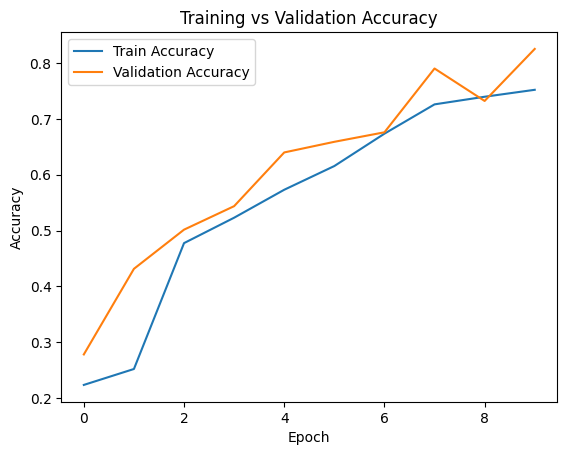

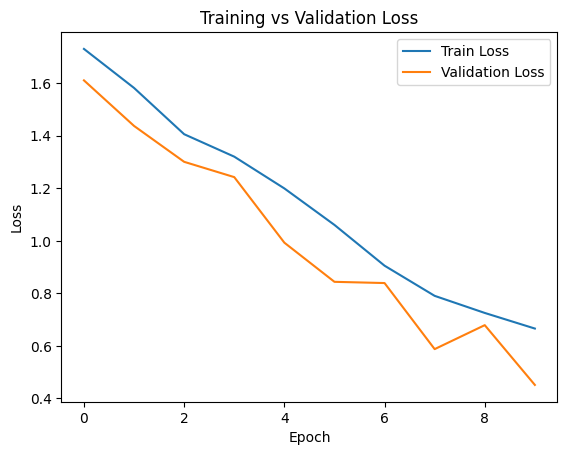

In [27]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

## Analisis

**Training vs Validation Loss**

Berdasarkan grafik, terlihat bahwa nilai training loss mengalami penurunan yang cukup konsisten dari sekitar 1.73 pada epoch awal menjadi sekitar 0.66 pada epoch terakhir.

Sementara itu, validation loss juga menunjukkan tren penurunan dari sekitar 1.61 menjadi 0.45, meskipun terdapat sedikit fluktuasi pada beberapa epoch (terutama di sekitar epoch 7–8).

Hal ini menunjukkan bahwa model semakin mampu meminimalkan kesalahan prediksi seiring bertambahnya proses training.

**Training vs Validation Accuracy**

Berdasarkan hasil training, nilai accuracy pada data training meningkat secara signifikan dari sekitar 22% pada epoch awal menjadi sekitar 75% pada epoch terakhir.

Sedangkan validation accuracy juga mengalami peningkatan dari sekitar 27% hingga mencapai 82%.

Peningkatan ini menunjukkan bahwa model mampu mempelajari pola dari data dengan baik dan performanya terus membaik selama proses training.

**Analisis Model**

Dari kedua hasil tersebut, dapat disimpulkan bahwa:
- Model tidak mengalami overfitting, karena nilai training dan validation menunjukkan tren yang sejalan
- Validation accuracy yang lebih tinggi dari training accuracy menunjukkan bahwa model memiliki kemampuan generalisasi yang baik
- Penurunan loss yang konsisten menunjukkan bahwa model semakin optimal dalam meminimalkan error
- Fluktuasi kecil pada validation loss merupakan hal yang wajar dalam proses training

# Nomor 2c
Modifikasi arsitektur AlexNet yang sudah dibuat. Anda bisa
menambahkan DropOut, Batch Normalization, dan sebagainya atau melakukan fine-tuning untuk
hyperparameter pada model ini. Anda juga bisa mengganti modelnya dengan arsitektur CNN lain
seperti DenseNet, EfficientNet, dan sebagainya. Jelaskan alasan modifikasi anda dan lakukan training
(minimal 10 epoch), serta analisis hasilnya.

In [28]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [29]:
improved_model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Conv Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Conv Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Fully Connected
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output
    layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Peningkatan dilakukan dengan menambahkan jumlah convolutional layer yang disusun dalam beberapa blok dengan jumlah filter yang meningkat secara bertahap (32 hingga 256). Hal ini bertujuan agar model mampu mengekstraksi fitur dari yang sederhana hingga kompleks. Selain itu, ditambahkan Batch Normalization pada setiap blok untuk menstabilkan proses training dan meningkatkan kemampuan generalisasi model.

Pada bagian fully connected layer, jumlah neuron diperbesar menjadi dua layer (256 dan 128 neuron) untuk memungkinkan model mempelajari hubungan yang lebih kompleks. Untuk mengurangi risiko overfitting, digunakan teknik Dropout dengan nilai 0.5 dan 0.3. Kombinasi dari peningkatan kedalaman jaringan, normalisasi, serta regularisasi ini diharapkan dapat meningkatkan akurasi model dan membuat model lebih robust terhadap data baru.

**Alasan Modifikasi**  
Modifikasi model dilakukan dengan mengganti arsitektur berbasis AlexNet menjadi Custom CNN yang lebih sederhana dan efisien. Penggunaan kernel kecil (3x3) serta penambahan beberapa convolutional block bertujuan untuk meningkatkan kemampuan model dalam menangkap fitur secara lebih detail dan bertahap, mulai dari pola sederhana hingga kompleks. Selain itu, peningkatan jumlah filter secara bertahap (32 hingga 256) memungkinkan proses ekstraksi fitur yang lebih kaya tanpa membuat model terlalu berat di awal layer.

Selain itu, ditambahkan Batch Normalization untuk menstabilkan proses training dan mempercepat konvergensi, serta Dropout untuk mengurangi risiko overfitting pada fully connected layer. Dibandingkan dengan arsitektur awal, modifikasi ini diharapkan dapat menghasilkan performa yang lebih baik dan generalisasi yang lebih kuat terhadap data baru.

In [30]:
improved_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,269,189 (50.62 MB)

 Trainable params: 13,268,229 (50.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [31]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

Selain modifikasi arsitektur, dilakukan juga peningkatan pada proses training dengan menerapkan teknik Early Stopping dan Reduce Learning Rate on Plateau. Early Stopping digunakan untuk menghentikan training secara otomatis ketika performa pada validation set tidak lagi membaik setelah beberapa epoch (patience = 4), sehingga dapat mencegah overfitting dan menghemat waktu komputasi. Selain itu, parameter restore_best_weights=True memastikan model yang digunakan adalah model dengan performa terbaik selama training.

Sementara itu, ReduceLROnPlateau digunakan untuk menurunkan learning rate secara adaptif ketika nilai validation loss tidak mengalami perbaikan (patience = 2). Dengan menurunkan learning rate sebesar faktor 0.3, model dapat melakukan fine-tuning pada tahap akhir training sehingga konvergensi menjadi lebih stabil dan berpotensi meningkatkan performa model secara keseluruhan.

In [32]:
improved_history = improved_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

Epoch 1/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 86s 716ms/step - accuracy: 0.5354 - loss: 1.6495 - val_accuracy: 0.2999 - val_loss: 5.8856 - learning_rate: 1.0000e-04
Epoch 2/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 63s 616ms/step - accuracy: 0.6933 - loss: 0.9396 - val_accuracy: 0.2999 - val_loss: 5.8818 - learning_rate: 1.0000e-04
Epoch 3/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 64s 620ms/step - accuracy: 0.7549 - loss: 0.8006 - val_accuracy: 0.5637 - val_loss: 1.1726 - learning_rate: 1.0000e-04
Epoch 4/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 63s 606ms/step - accuracy: 0.7838 - loss: 0.7253 - val_accuracy: 0.8225 - val_loss: 0.4936 - learning_rate: 1.0000e-04
Epoch 5/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 62s 604ms/step - accuracy: 0.7850 - loss: 0.7120 - val_accuracy: 0.8255 - val_loss: 0.4654 - learning_rate: 1.0000e-04
Epoch 6/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 65s 633ms/step - accuracy: 0.8154 - loss: 0.6070 - val_accuracy: 0.9137 - val_loss: 0.2785 - learning_rate: 1.0000e-04
Epoch 7/20
103/103 ━━━━━━━━━━━━━━━━━━━━ 64s 62

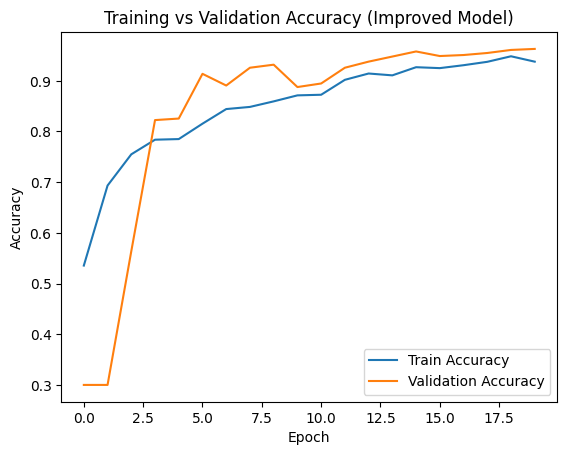

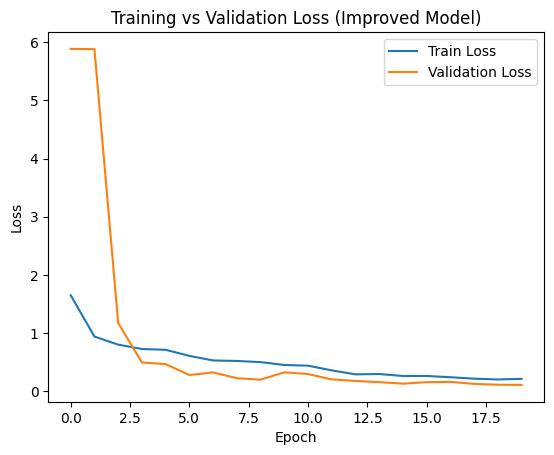

In [33]:
# Accuracy
plt.figure()
plt.plot(improved_history.history['accuracy'], label='Train Accuracy')
plt.plot(improved_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (Improved Model)')
plt.legend()
plt.show()


# Loss
plt.figure()
plt.plot(improved_history.history['loss'], label='Train Loss')
plt.plot(improved_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Improved Model)')
plt.legend()
plt.show()

Berdasarkan hasil training, model menunjukkan peningkatan performa yang signifikan. Nilai accuracy pada data training meningkat secara konsisten hingga mencapai sekitar 93-94%, sedangkan validation accuracy mencapai sekitar 96%. Selain itu, nilai loss pada training dan validation juga mengalami penurunan yang stabil hingga mendekati 0.1. Hal ini menunjukkan bahwa model mampu mempelajari pola data dengan baik. Pada awal epoch, terlihat adanya lonjakan validation loss yang cukup tinggi, namun setelah beberapa epoch, model mulai stabil dan mengalami peningkatan performa yang signifikan.

Perbandingan antara training dan validation menunjukkan bahwa tidak terjadi overfitting yang signifikan, karena kedua kurva memiliki tren yang sejalan dan gap yang relatif kecil. Bahkan, validation accuracy yang lebih tinggi dari training accuracy mengindikasikan bahwa model memiliki kemampuan generalisasi yang baik. Hal ini juga didukung oleh penggunaan Batch Normalization, Dropout, serta teknik training seperti Early Stopping dan ReduceLROnPlateau yang membantu menjaga stabilitas dan meningkatkan performa model secara keseluruhan.

# No 2d
Lakukan evaluasi performa model anda pada data test dengan
menggunakan minimal 3 evaluation metrics. Analisis, jelaskan, dan simpulkan hasilnya. Lalu, berikan
saran untuk pengembangan lebih lanjut dari model anda

## Base Model Evaluation

In [34]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 241ms/step - accuracy: 0.8250 - loss: 0.4785
Test Loss : 0.4785454273223877
Test Accuracy : 0.8250496983528137


## Improved Model Evaluation

In [35]:
test_loss, test_acc = improved_model.evaluate(test_generator)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 229ms/step - accuracy: 0.9583 - loss: 0.1126
Test Loss : 0.1125703752040863
Test Accuracy : 0.9582505226135254


## Test Prediction

In [36]:
from sklearn.metrics import classification_report

test_generator.reset()

y_pred = model.predict(test_generator)
y_pred = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 219ms/step
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.94      0.81      0.87       305
      Cherry Normal leaf       0.71      0.66      0.68       143
       Cherry brown_spot       0.73      0.84      0.78       168
 Cherry purple leaf spot       0.94      0.93      0.94       273
Cherry_shot hole disease       0.65      0.79      0.71       117

                accuracy                           0.83      1006
               macro avg       0.79      0.81      0.80      1006
            weighted avg       0.84      0.83      0.83      1006



**Evaluasi Performa Model pada Data Test**

Evaluasi performa model dilakukan menggunakan beberapa metrik, yaitu accuracy, precision, recall, dan f1-score. Berdasarkan hasil pengujian, base model memperoleh accuracy sebesar 82.50% dengan loss sebesar 0.4785, sedangkan improved model menunjukkan peningkatan signifikan dengan accuracy sebesar 95.83% dan loss sebesar 0.1126. Hal ini menunjukkan bahwa model hasil perbaikan memiliki kemampuan prediksi yang jauh lebih baik dibandingkan model awal.

Berdasarkan classification report pada base model, nilai precision, recall, dan f1-score masih bervariasi antar kelas. Sebagai contoh, kelas Cherry Leaf Scorch memiliki f1-score sebesar 0.87, sedangkan kelas Cherry Normal leaf hanya sekitar 0.68. Nilai macro average f1-score sebesar 0.80 menunjukkan bahwa performa model belum merata pada semua kelas. Sementara itu, weighted average f1-score sebesar 0.83 menunjukkan bahwa model cukup baik secara keseluruhan, namun masih terdapat ketidakseimbangan performa antar kelas.

**Analisis**

Performa improved model yang jauh lebih tinggi menunjukkan bahwa modifikasi arsitektur CNN, penggunaan Batch Normalization, Dropout, serta strategi training seperti Early Stopping dan ReduceLROnPlateau memberikan dampak positif terhadap kemampuan model dalam melakukan generalisasi. Nilai loss yang lebih rendah juga menunjukkan bahwa model mampu meminimalkan error dengan lebih baik.

Selain itu, dari grafik training terlihat bahwa tidak terjadi overfitting yang signifikan karena nilai training dan validation memiliki pola yang seimbang. Hal ini memperkuat bahwa model improved lebih stabil dan mampu bekerja lebih optimal dibandingkan base model.

**Saran Pengembangan**

Untuk pengembangan lebih lanjut, beberapa hal yang dapat dilakukan antara lain:

- Menambahkan variasi data augmentation untuk meningkatkan keberagaman data.
- Menggunakan transfer learning (misalnya ResNet atau EfficientNet) untuk mendapatkan performa yang lebih tinggi.
- Melakukan hyperparameter tuning seperti learning rate, batch size, dan jumlah layer.
- Mengatasi kemungkinan class imbalance agar performa tiap kelas lebih merata.